In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas
import recon_histograms as hist

In [53]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)
importlib.reload(hist)

<module 'recon_histograms' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../recon_histograms.py'>

## MC chi2 cut study

Reads MC simulation output from `gen_signal_model_mc.py` and applies the same quality cuts
as `recon_histograms.py`.  The goal is to understand how the chi2 cut affects the measured
spectrum — particularly at high pressures where pile-up (≥2 events in one 256-sample
sub-window) causes elevated chi2 and biases the amplitude histogram.

Each MC file contains one pressure; `hist.read_recon_mc_file` wraps it into the standard
`recon_output` format so `hist.get_summed_histogram` can be called without modification.

In [40]:
# ── Configuration ────────────────────────────────────────────────────────────
mc_dir = r'../../data_processed/signal_model_mc/mc_xe'

bins         = np.arange(0, 2000, 25)
bc           = 0.5 * (bins[:-1] + bins[1:])
T_search     = 2**8 / 5e6          # 51.2 µs — time per search sub-window

# ── Pressures to plot (set to None to plot all) ───────────────────────────────
plot_pressures = [0, 1e-8, 5e-8, 1e-7, 5e-7, 1e-6]   # e.g. [1e-8, 1e-7, 1e-6] or None for all

# ── Discover and sort MC files by pressure ───────────────────────────────────
mc_files = sorted(glob.glob(os.path.join(mc_dir, '*.hdf5')))
print(f'Found {len(mc_files)} MC files in {mc_dir}:')
for f in mc_files:
    print(' ', os.path.basename(f))

Found 10 MC files in ../../data_processed/signal_model_mc/mc_xe:
  xe_0.0e+00mbar_mc.hdf5
  xe_1.0e-06mbar_mc.hdf5
  xe_1.0e-07mbar_mc.hdf5
  xe_1.0e-08mbar_mc.hdf5
  xe_3.0e-07mbar_mc.hdf5
  xe_3.0e-08mbar_mc.hdf5
  xe_5.0e-07mbar_mc.hdf5
  xe_5.0e-08mbar_mc.hdf5
  xe_7.0e-07mbar_mc.hdf5
  xe_7.0e-08mbar_mc.hdf5


In [41]:
# ── Load MC files and build histograms ───────────────────────────────────────
# For each pressure file, call hist.get_summed_histogram with all cuts.
#
# Also derive a per-sub-window injected-event count from mc_injected truth info,
# so signal and noise sub-windows can be separated when building histograms.

pressures   = []
hh_allcuts  = []   # 'all'   stage — full pipeline
hh_nochi2   = []   # 'drive' stage — before chi2 and double-count removal
hh_nocuts   = []   # 'nocuts' stage — no cuts at all
mc_meta     = []
mc_injected_all = []   # per-file injected event dicts

for fpath in mc_files:
    recon_out, mc_attrs, mc_injected = hist.read_recon_mc_file(fpath)
    _, hh = hist.get_summed_histogram(recon_out, bins,
                                      remove_doublecounts=True,
                                      apply_noise_cut=True,
                                      apply_drive_cut=True,
                                      apply_chi2_cut=True)
    # read pressure from recon_output (index 6 is pressure list)
    p_mbar = float(recon_out[6][0])

    pressures.append(p_mbar)
    hh_allcuts.append(hh['all'].copy())
    hh_nochi2.append(hh['drive'].copy())    # after noise+drive, before chi2
    hh_nocuts.append(hh['nocuts'].copy())
    mc_meta.append(mc_attrs)
    mc_injected_all.append(mc_injected)

pressures  = np.array(pressures)
sort_order = np.argsort(pressures)
pressures  = pressures[sort_order]
hh_allcuts = [hh_allcuts[i] for i in sort_order]
hh_nochi2  = [hh_nochi2[i]  for i in sort_order]
hh_nocuts  = [hh_nocuts[i]  for i in sort_order]
mc_meta    = [mc_meta[i]    for i in sort_order]
mc_injected_all = [mc_injected_all[i] for i in sort_order]

print('Loaded pressures (mbar):', pressures)
print('MC params:', {k: mc_meta[0][k] for k in ('mc_gas','mc_T_gas','mc_T_sensor','mc_alpha')})
if mc_injected_all[0] is not None:
    for i, p in enumerate(pressures):
        n_inj = len(mc_injected_all[i]['q_true_kev'])
        print(f'  {p:.1e} mbar: {n_inj} injected events')
else:
    print('  (no mc_injected truth info — re-run gen_signal_model_mc.py)')

Loaded pressures (mbar): [0.e+00 1.e-08 3.e-08 5.e-08 7.e-08 1.e-07 3.e-07 5.e-07 7.e-07 1.e-06]
MC params: {'mc_gas': 'xe', 'mc_T_gas': 293, 'mc_T_sensor': 293.05, 'mc_alpha': 0.9}
  0.0e+00 mbar: 0 injected events
  1.0e-08 mbar: 22691 injected events
  3.0e-08 mbar: 67551 injected events
  5.0e-08 mbar: 112779 injected events
  7.0e-08 mbar: 158820 injected events
  1.0e-07 mbar: 225280 injected events
  3.0e-07 mbar: 677170 injected events
  5.0e-07 mbar: 1125352 injected events
  7.0e-07 mbar: 1579345 injected events
  1.0e-06 mbar: 2257073 injected events


In [30]:
# ── Build signal / noise histograms using mc_injected truth info ─────────────
#
# Signal classification (matches mc_search_effects.ipynb):
#   A detected sub-window is "signal" if the argmax position is within
#   fwhm_samps of any injection position in the same analysis window.
#   This tests whether the detection found a real pulse, not just whether
#   something was injected nearby.  A noise fluctuation winning argmax far
#   from all injection peaks is correctly counted as noise.
#
# Cuts mirror recon_histograms.py exactly (noise, drive, chi2, DC removal).

_lb        = hist.lb                        # 512
_swl       = hist.search_window_length      # 256
_noise_thr = hist.noise_threshold_kev
_chi2_thr  = hist.chi2_threshold
_drive_thr = hist.normalized_drive_power_threshold
_drive_freq = hist.drive_freq
_ref_freq   = hist.ref_freq

# ── Pulse FWHM from calibration template (match threshold) ───────────────────
_cal = np.load('../../data_processed/pulse_calibration/sphere_20260215/'
               'sphere_20260215_impulse_recon_combined.npz')
_ps_raw  = _cal['ps_20v']
_peak    = int(np.argmax(_ps_raw))
_ps_norm = _ps_raw / _ps_raw[_peak]
_half    = _swl // 2
_pulse_tpl = _ps_norm[_peak - _half : _peak + _half]
fwhm_samps = int(np.sum(_pulse_tpl > 0.5))
print(f'Match threshold: ±{fwhm_samps} samples = ±{fwhm_samps/5e6*1e6:.1f} µs')

hh_signal     = []   # signal sub-windows (argmax within fwhm_samps of injection), all cuts
hh_noise_only = []   # all other sub-windows, all cuts

for fpath in [mc_files[j] for j in sort_order]:
    recon_out, _, mc_inj = hist.read_recon_mc_file(fpath)
    assert mc_inj is not None, f'No mc_injected in {fpath} — re-run gen_signal_model_mc.py'

    amps       = recon_out[0][0]   # (n_win, n_sw)
    good_det   = recon_out[1][0]
    noise_lv   = recon_out[2][0]
    chi2       = recon_out[3][0]
    drv_pwr    = recon_out[4][0]
    f_res      = recon_out[5][0]
    idx_in_win = recon_out[7][0]   # (n_win, n_sw) — detected argmax positions
    a2k        = recon_out[9][0]

    n_win, n_sw = amps.shape

    # ── Per-window injection lookup (pre-group for speed) ────────────────────
    inj_pos_by_win = {}
    for ev_i, w in enumerate(mc_inj['window_idx']):
        inj_pos_by_win.setdefault(int(w), []).append(int(mc_inj['positions'][ev_i]))

    # ── Signal flag: argmax within fwhm_samps of any injection in same window ─
    is_signal = np.zeros((n_win, n_sw), dtype=bool)
    for w, inj_positions in inj_pos_by_win.items():
        inj_arr = np.array(inj_positions)                    # (n_inj,)
        det_pos = idx_in_win[w]                              # (n_sw,)
        dists   = np.abs(det_pos[:, None] - inj_arr[None, :])  # (n_sw, n_inj)
        is_signal[w] = np.any(dists <= fwhm_samps, axis=1)

    # ── Apply cuts (same logic as get_summed_histogram) ──────────────────────
    noise_ok = noise_lv * a2k < _noise_thr
    norm_drive = (drv_pwr * (f_res**2 - _drive_freq**2)**2
                  / (_ref_freq**2 - _drive_freq**2)**2)
    drive_ok  = norm_drive > _drive_thr
    win_mask  = good_det & noise_ok & drive_ok

    amps_cut  = np.array(amps, dtype=np.float64)
    amps_cut[chi2 >= _chi2_thr] = np.nan
    amps_final = hist.throw_away_doublecounts(
        amps_cut, win_mask, idx_in_win, file_amp2kev=a2k)

    # ── Split and histogram ───────────────────────────────────────────────────
    good_amps   = amps_final[win_mask]
    good_is_sig = is_signal[win_mask]

    sig_vals = np.abs(good_amps[good_is_sig][~np.isnan(good_amps[good_is_sig])]) * a2k
    noi_vals = np.abs(good_amps[~good_is_sig][~np.isnan(good_amps[~good_is_sig])]) * a2k
    hh_sig, _ = np.histogram(sig_vals, bins)
    hh_noi, _ = np.histogram(noi_vals, bins)

    hh_signal.append(hh_sig)
    hh_noise_only.append(hh_noi)

# Sanity check
for i, p in enumerate(pressures):
    diff = np.sum(np.abs(hh_signal[i] + hh_noise_only[i] - hh_allcuts[i]))
    print(f'{p:.1e} mbar: {np.sum(hh_signal[i]):>8,} signal sw, '
          f'{np.sum(hh_noise_only[i]):>10,} noise sw  |  Δ vs allcuts = {diff}')

Match threshold: ±32 samples = ±6.4 µs
0.0e+00 mbar:        0 signal sw,  1,013,723 noise sw  |  Δ vs allcuts = 0
1.0e-08 mbar:    8,220 signal sw,  1,004,290 noise sw  |  Δ vs allcuts = 0
3.0e-08 mbar:   24,291 signal sw,    986,430 noise sw  |  Δ vs allcuts = 0
5.0e-08 mbar:   40,080 signal sw,    968,411 noise sw  |  Δ vs allcuts = 0
7.0e-08 mbar:   55,564 signal sw,    950,674 noise sw  |  Δ vs allcuts = 0
1.0e-07 mbar:   77,617 signal sw,    925,703 noise sw  |  Δ vs allcuts = 0
3.0e-07 mbar:  207,229 signal sw,    772,326 noise sw  |  Δ vs allcuts = 0
5.0e-07 mbar:  305,071 signal sw,    646,697 noise sw  |  Δ vs allcuts = 0
7.0e-07 mbar:  379,048 signal sw,    541,161 noise sw  |  Δ vs allcuts = 0
1.0e-06 mbar:  454,383 signal sw,    413,680 noise sw  |  Δ vs allcuts = 0


## Rate spectra: effect of chi2 cut across pressures

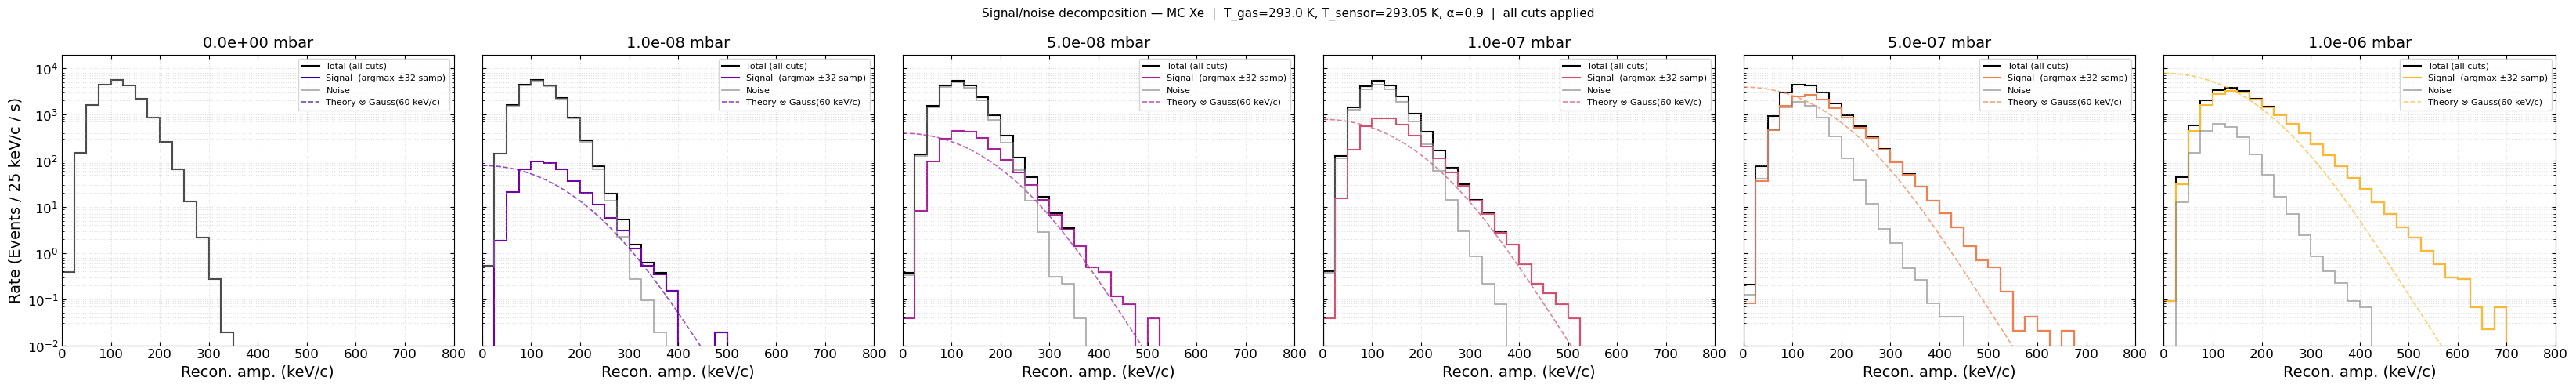

In [31]:
# ── Signal / noise decomposition — one panel per selected pressure ────────────
dq = bins[1] - bins[0]

n_panels = len(p_sel)
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax, p, c, hh_tot, hh_sig, hh_noi in zip(
        axes, p_sel, colors, hh_all_sel, hh_signal_sel, hh_noise_sel):

    norm = np.sum(hh_tot) * T_search   # same livetime for all three curves
    if norm == 0:
        continue

    ax.stairs(hh_tot / norm, bins, color='k',    lw=1.5, label='Total (all cuts)')
    ax.stairs(hh_sig / norm, bins, color=c,      lw=1.5, label=f'Signal  (argmax ±{fwhm_samps} samp)')
    ax.stairs(hh_noi / norm, bins, color='gray', lw=1.2, alpha=0.7, label='Noise')
    ax.plot(qq_kev, drdqz_smeared[p] * dq, '--', color=c, lw=1.2, alpha=0.7,
            label=f'Theory ⊗ Gauss({sigma_smear_kev:.0f} keV/c)')

    ax.set_yscale('log')
    ax.set_xlim(0, 800)
    ax.set_ylim(1e-2, 2e4)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_title(f'{p:.1e} mbar')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', ls=':', alpha=0.4)

axes[0].set_ylabel(f'Rate (Events / {dq:.0f} keV/c / s)')
fig.suptitle(
    f'Signal/noise decomposition — MC Xe  |  '
    f'T_gas={T_gas} K, T_sensor={T_sensor} K, α={alpha}  |  all cuts applied',
    fontsize=11)
fig.tight_layout()

## Signal / noise decomposition

Each detected sub-window amplitude is classified as **signal** (argmax within ±`fwhm_samps`
of an injected peak) or **noise** (no injection nearby).  Both components share the same
livetime normalisation so they stack to the total rate.

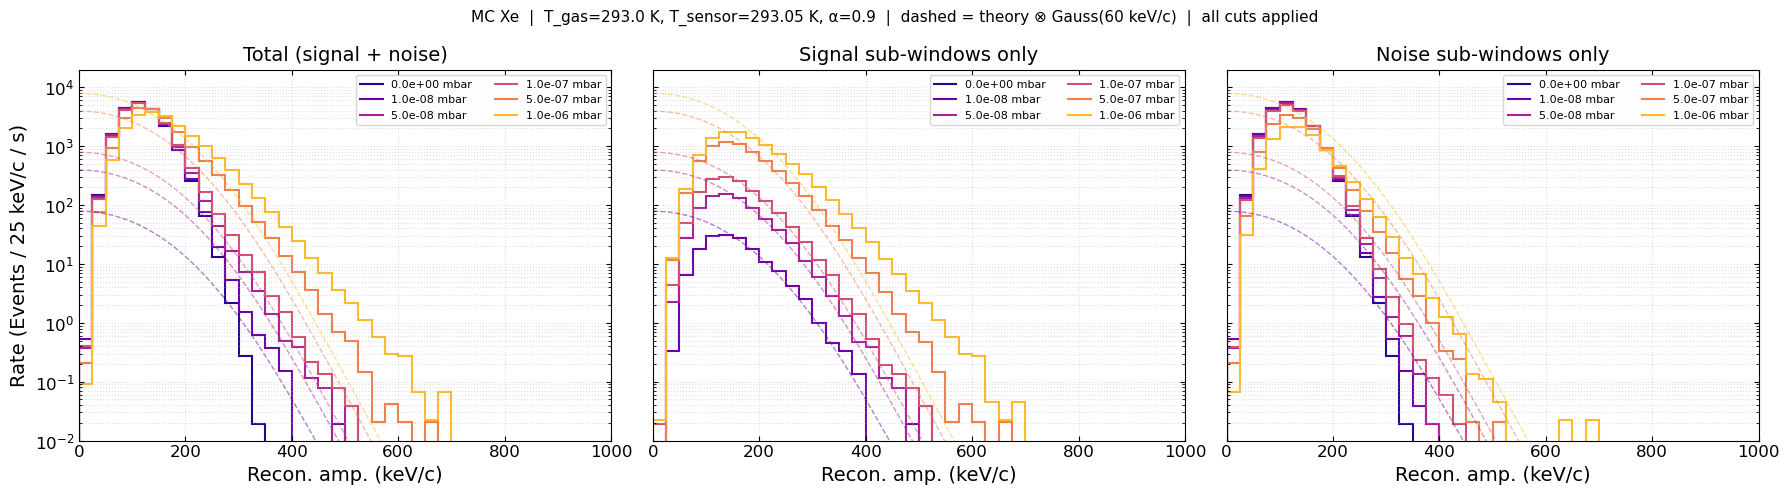

In [33]:
# ── Theory spectra for reference ─────────────────────────────────────────────
T_gas    = float(mc_meta[0]['mc_T_gas'])
T_sensor = float(mc_meta[0]['mc_T_sensor'])
alpha    = float(mc_meta[0]['mc_alpha'])
sigma_smear_kev = 60.0   # keV/c — matches sigma_noise_kev in gen_signal_model_mc.py

qq_kev = np.linspace(0.5, 2000, 4000)
drdqz_theory  = {}
drdqz_smeared = {}
for p in pressures:
    drdq = calc_gas.dgamma_dp_tot_noneq(qq_kev, 131.293, p_mbar=p, alpha=alpha,
                                         T_gas=T_gas, T_sensor=T_sensor, sphere_radius=50e-9)
    _, drdqz = calc_gas.get_drdqz(qq_kev, drdq)
    _, drdqz_smear = calc_gas.smear_drdqz_gauss(qq_kev, drdqz, sigma_smear_kev)
    drdqz_theory[p]  = drdqz
    drdqz_smeared[p] = drdqz_smear

# ── Filter to selected pressures ─────────────────────────────────────────────
if plot_pressures is not None:
    sel = np.array([np.argmin(np.abs(pressures - p)) for p in plot_pressures])
    sel = np.unique(sel)
else:
    sel = np.arange(len(pressures))

p_sel           = pressures[sel]
hh_all_sel      = [hh_allcuts[i]   for i in sel]
hh_nochi2_sel   = [hh_nochi2[i]    for i in sel]
hh_signal_sel   = [hh_signal[i]    for i in sel]
hh_noise_sel    = [hh_noise_only[i] for i in sel]
colors = plt.colormaps['plasma'](np.linspace(0.05, 0.85, len(p_sel)))

# ── Normalisation: use total (signal+noise) livetime for all curves ──────────
# This way signal + noise rates add up to the total rate.
dq = bins[1] - bins[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, hh_list, title in [
    (axes[0], hh_all_sel,    'Total (signal + noise)'),
    (axes[1], hh_signal_sel, 'Signal sub-windows only'),
    (axes[2], hh_noise_sel,  'Noise sub-windows only'),
]:
    for idx, (hh, p, c) in enumerate(zip(hh_list, p_sel, colors)):
        # Normalise by total livetime (signal+noise combined)
        norm = np.sum(hh_all_sel[idx]) * T_search
        if norm == 0:
            continue
        ax.stairs(hh / norm, bins, color=c, linewidth=1.5, label=f'{p:.1e} mbar')
        ax.plot(qq_kev, drdqz_smeared[p] * dq, color=c,
                ls='--', lw=1.0, alpha=0.5)

    ax.set_yscale('log')
    ax.set_xlim(0, 1000)
    ax.set_ylim(1e-2, 2e4)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_title(title)
    ax.grid(True, which='both', ls=':', alpha=0.4)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel(f'Rate (Events / {dq:.0f} keV/c / s)')
fig.suptitle(f'MC Xe  |  T_gas={T_gas} K, T_sensor={T_sensor} K, α={alpha}  '
             f'|  dashed = theory ⊗ Gauss({sigma_smear_kev:.0f} keV/c)  '
             f'|  all cuts applied', fontsize=11)
fig.tight_layout()

## Chi2 vs amplitude 2D histograms

After noise + drive cuts, before chi2 cut.  Top row: all sub-windows.  Bottom row: signal
sub-windows only (argmax within ±`fwhm_samps` of an injection).  Dashed line = chi2
threshold.

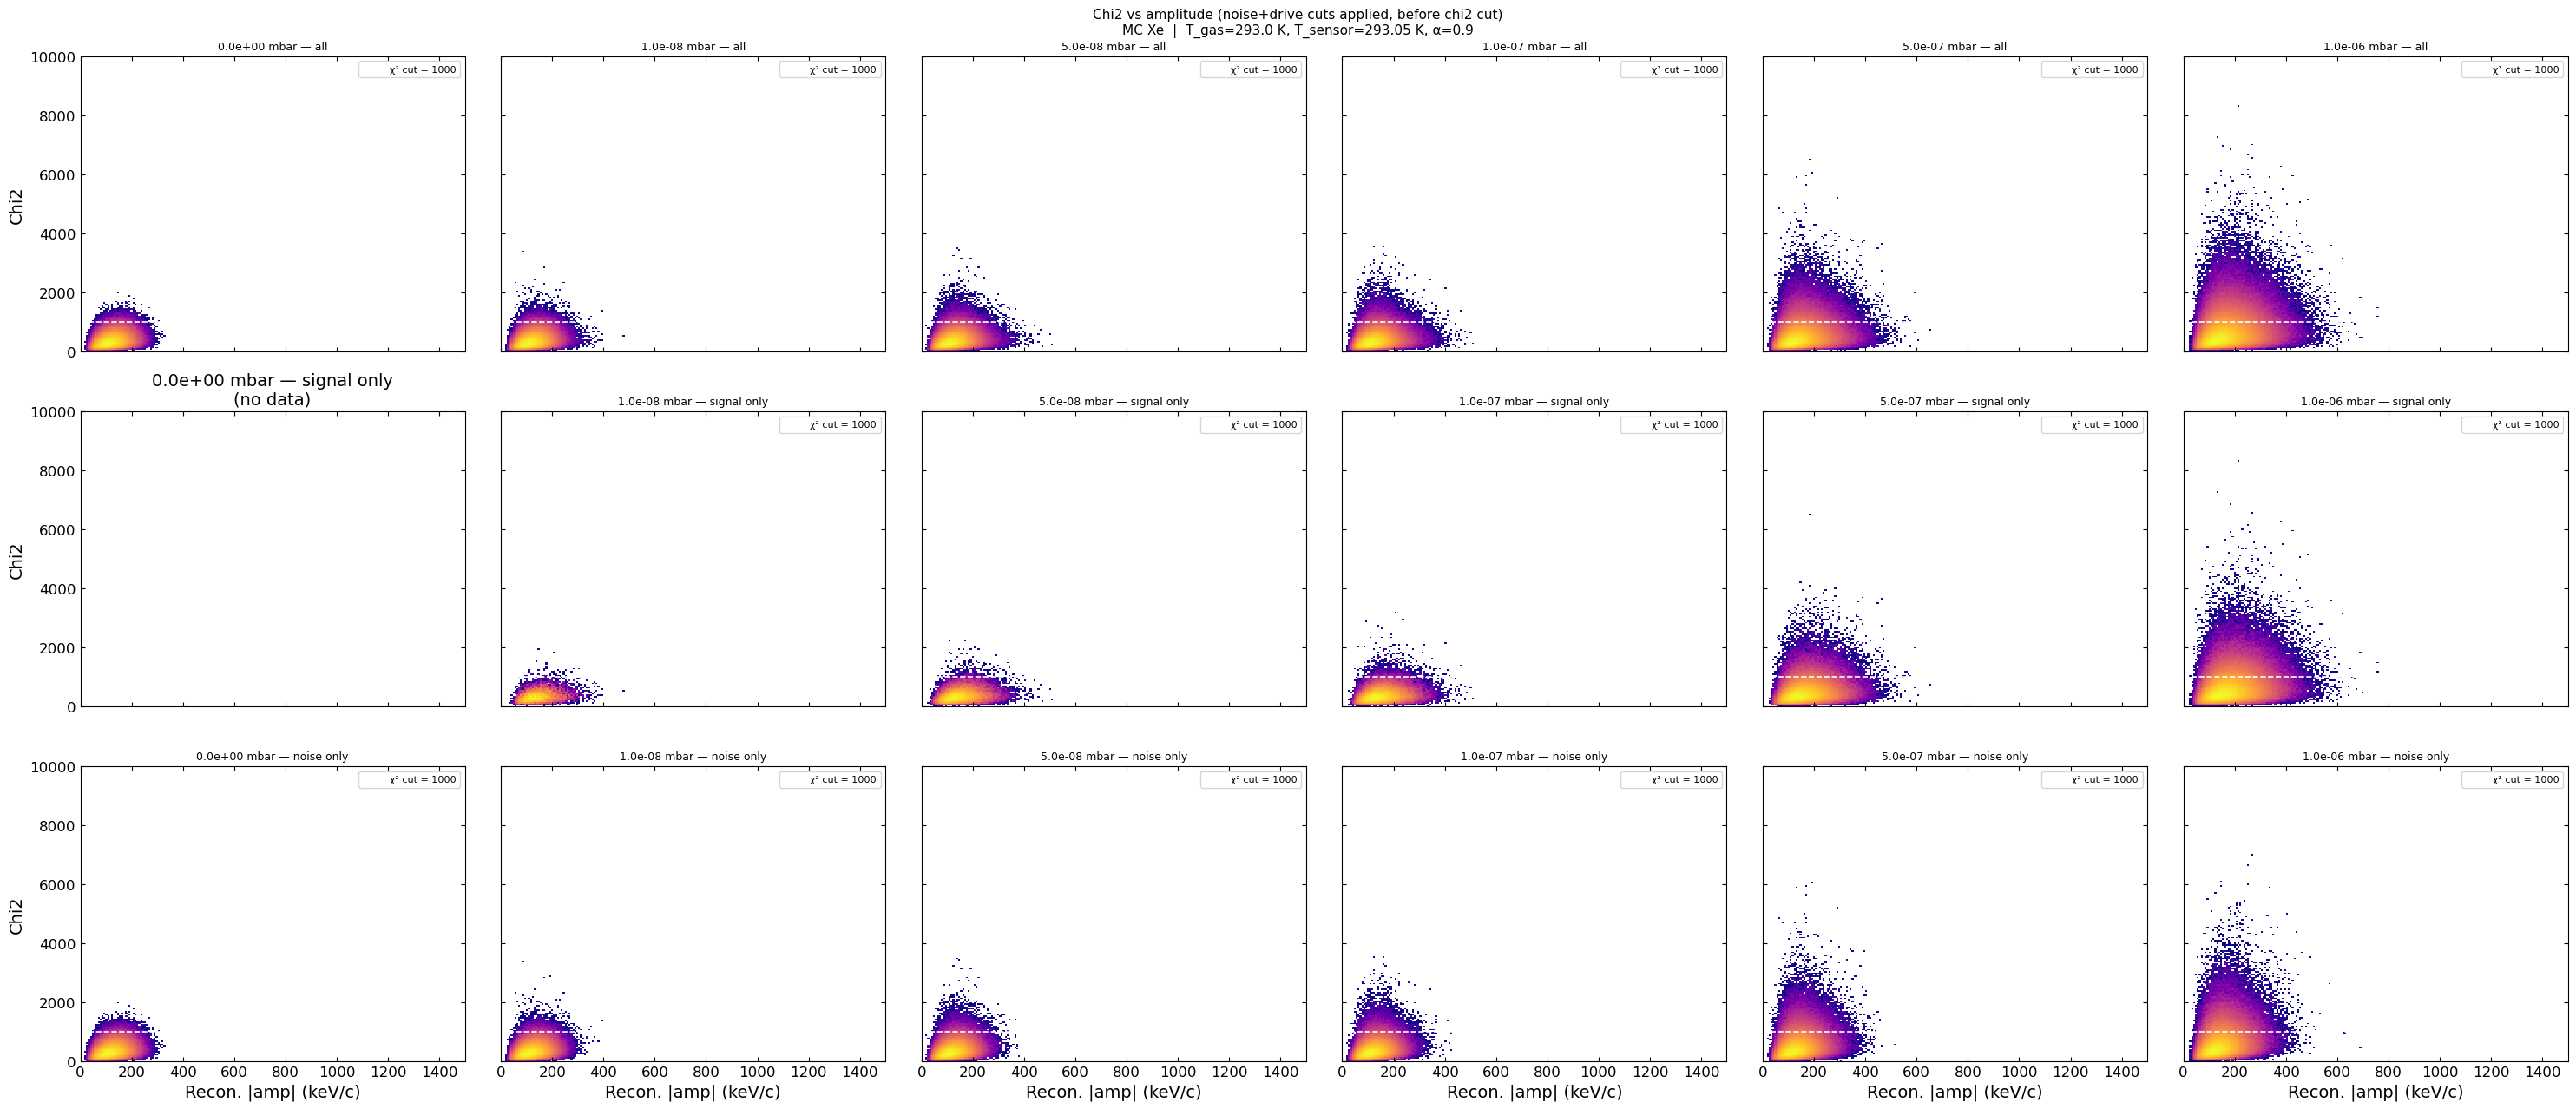

In [39]:
xbins = np.linspace(0,    1500, 200)
ybins = np.linspace(0,   10000, 200)

n_panels = len(p_sel)
fig, axes = plt.subplots(3, n_panels, figsize=(5 * n_panels, 13), sharex=True, sharey=True)
if n_panels == 1:
    axes = axes.reshape(3, 1)

for col, (p, fpath) in enumerate(zip(p_sel,
        [mc_files[sort_order[i]] for i in sel])):

    recon_out, _, mc_inj = hist.read_recon_mc_file(fpath)

    amps       = recon_out[0][0]   # (n_win, n_sw)
    good_det   = recon_out[1][0]
    noise_lv   = recon_out[2][0]
    chi2       = recon_out[3][0]
    drv_pwr    = recon_out[4][0]
    f_res      = recon_out[5][0]
    idx_in_win = recon_out[7][0]
    a2k        = recon_out[9][0]

    n_win, n_sw = amps.shape

    # ── Noise + drive cuts only (no chi2 cut) ────────────────────────────────
    noise_ok   = noise_lv * a2k < _noise_thr
    norm_drive = (drv_pwr * (f_res**2 - _drive_freq**2)**2
                  / (_ref_freq**2  - _drive_freq**2)**2)
    drive_ok   = norm_drive > _drive_thr
    win_mask   = good_det & noise_ok & drive_ok

    amp_kev_all = np.abs(amps[win_mask]).ravel() * a2k
    chi2_all    = chi2[win_mask].ravel()

    # ── Signal flag using argmax proximity ───────────────────────────────────
    is_sig = np.zeros((n_win, n_sw), dtype=bool)
    if mc_inj is not None:
        inj_pos_by_win = {}
        for ev_i, w in enumerate(mc_inj['window_idx']):
            inj_pos_by_win.setdefault(int(w), []).append(int(mc_inj['positions'][ev_i]))
        for w, inj_positions in inj_pos_by_win.items():
            inj_arr = np.array(inj_positions)
            dists   = np.abs(idx_in_win[w, :, None] - inj_arr[None, :])
            is_sig[w] = np.any(dists <= fwhm_samps, axis=1)

    sig_mask    = is_sig[win_mask].ravel()
    amp_kev_sig = amp_kev_all[sig_mask]
    chi2_sig    = chi2_all[sig_mask]
    amp_kev_noi = amp_kev_all[~sig_mask]
    chi2_noi    = chi2_all[~sig_mask]

    # ── Plot ─────────────────────────────────────────────────────────────────
    for ax, amp_vals, chi2_vals, title in [
        (axes[0, col], amp_kev_all, chi2_all,    f'{p:.1e} mbar — all'),
        (axes[1, col], amp_kev_sig, chi2_sig,    f'{p:.1e} mbar — signal only'),
        (axes[2, col], amp_kev_noi, chi2_noi,    f'{p:.1e} mbar — noise only'),
    ]:
        if len(amp_vals) == 0:
            ax.set_title(title + '\n(no data)')
            continue
        hh, _, _ = np.histogram2d(amp_vals, chi2_vals, bins=(xbins, ybins))
        ax.pcolormesh(xbins, ybins, hh.T,
                      norm=mcolors.LogNorm(vmin=1), cmap='plasma')
        ax.axhline(_chi2_thr, color='w', ls='--', lw=1.2,
                   label=f'χ² cut = {_chi2_thr:.0f}')
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(False)

for ax in axes[2, :]:
    ax.set_xlabel('Recon. |amp| (keV/c)')
for ax in axes[:, 0]:
    ax.set_ylabel('Chi2')

fig.suptitle(
    f'Chi2 vs amplitude (noise+drive cuts applied, before chi2 cut)\n'
    f'MC Xe  |  T_gas={T_gas} K, T_sensor={T_sensor} K, α={alpha}',
    fontsize=11)
fig.tight_layout()

## Effect of chi2 threshold on the final spectrum

In [60]:
# ── Chi2 threshold scan ───────────────────────────────────────────────────────
chi2_thresholds = [300, 600, 1000, 1500, 2000, np.inf]   # edit as needed

def build_hh_at_chi2_thr(fpath, bins, thr):
    """Return the 'all'-stage histogram for a single MC file at a given chi2 threshold."""
    recon_out, _, _ = hist.read_recon_mc_file(fpath)
    _, hh = hist.get_summed_histogram(
        recon_out, bins,
        remove_doublecounts=True,
        apply_noise_cut=True,
        apply_drive_cut=True,
        apply_chi2_cut=(thr != np.inf),
        chi2_threshold_override=(None if thr == np.inf else thr),
    )
    return hh['all']

# Pre-build for all (pressure, threshold) combinations
hh_thr = {}
for i, fpath in enumerate(mc_files[j] for j in sort_order):
    p = pressures[i]
    # if p not in p_sel:
    #     continue
    for thr in chi2_thresholds:
        hh_thr[(p, thr)] = build_hh_at_chi2_thr(fpath, bins, thr)

thr_colors = plt.colormaps['cool'](np.linspace(0.05, 0.95, len(chi2_thresholds)))
dq = bins[1] - bins[0]

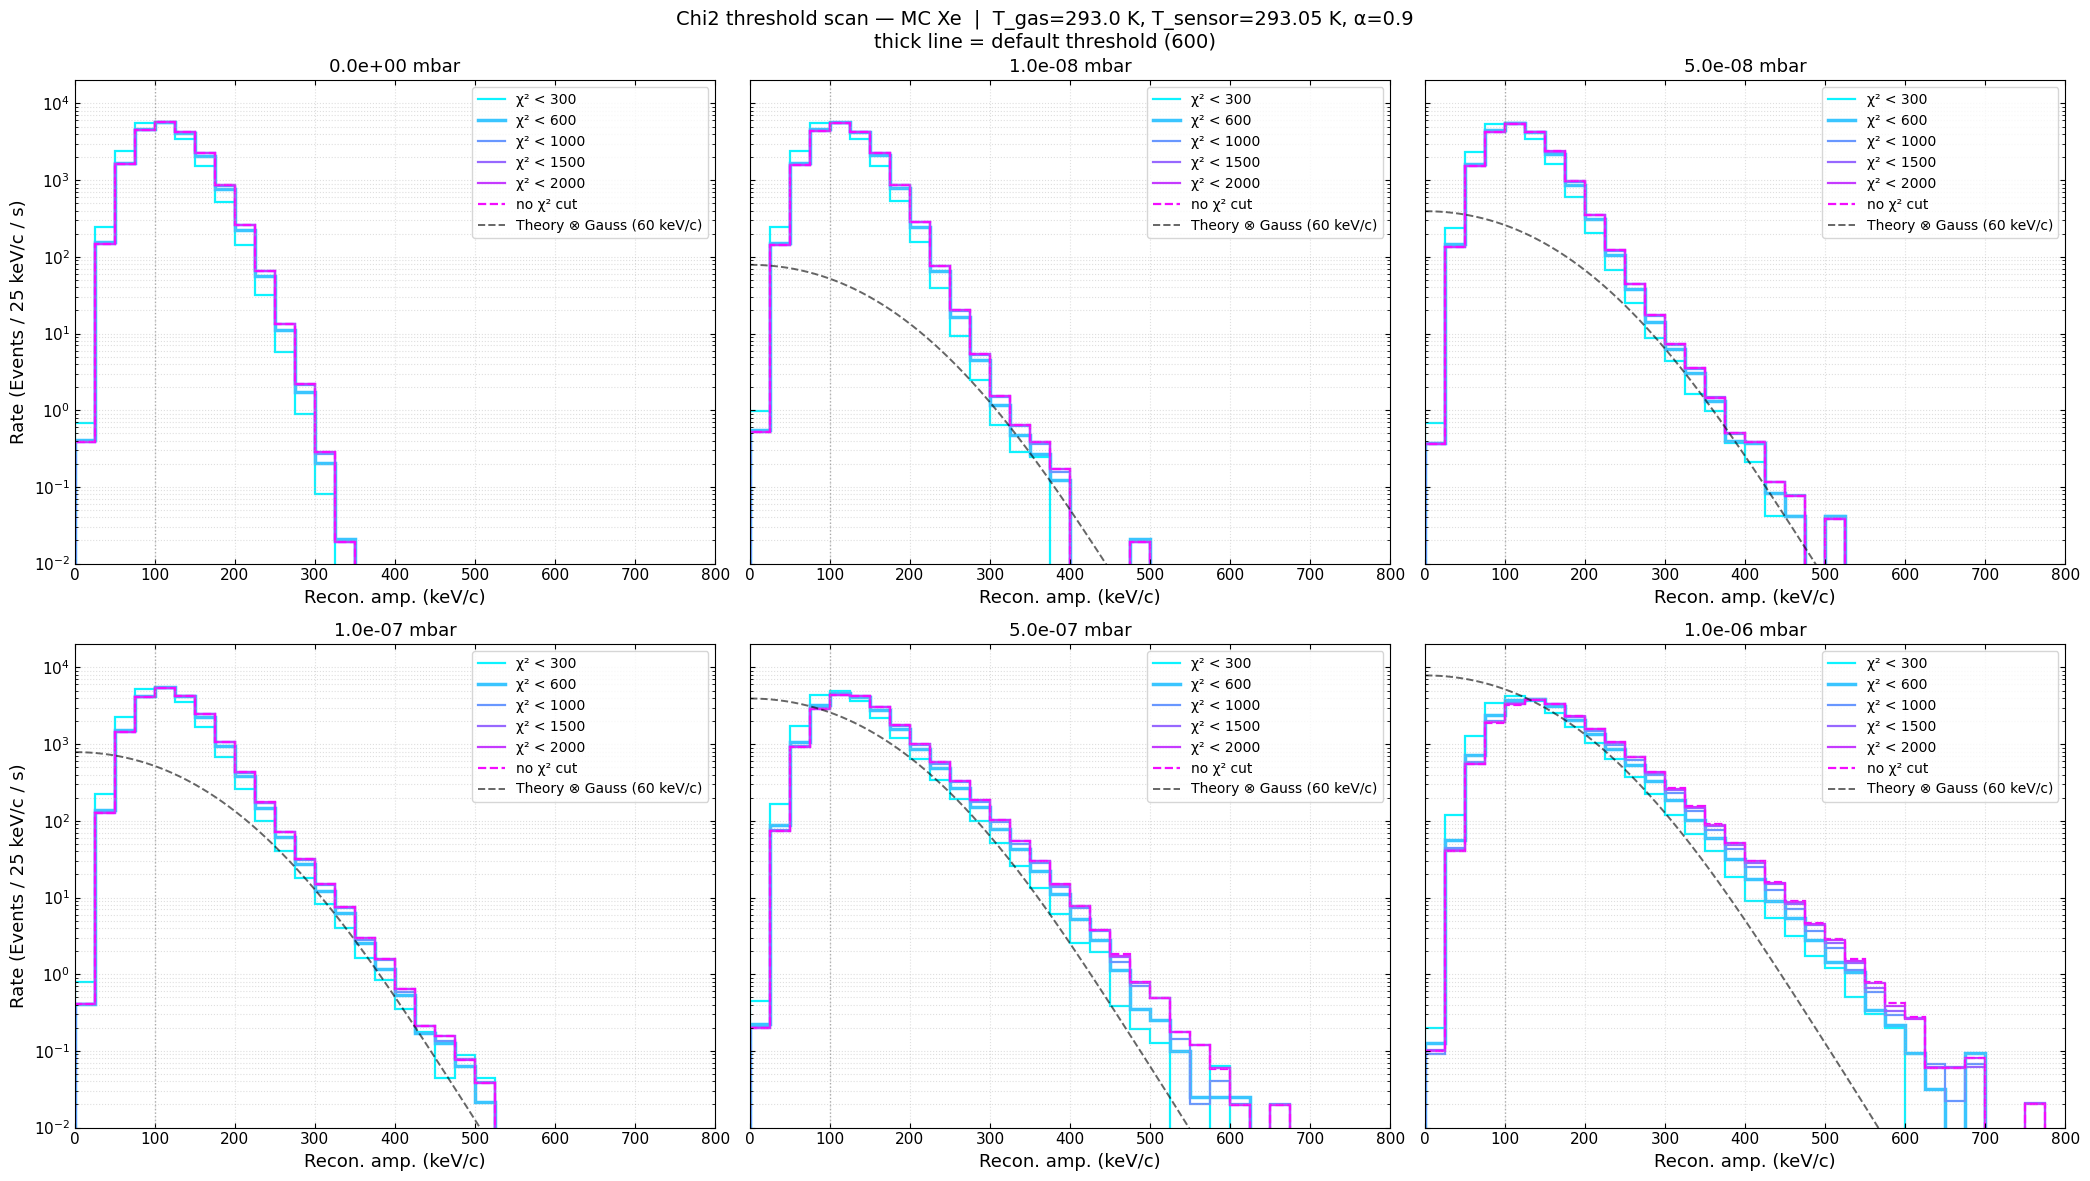

In [61]:
ncols = 3
nrows = int(np.ceil(len(p_sel) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows), sharey=True)
axes_flat = np.array(axes).ravel()

for ax_idx, p in enumerate(p_sel):
    ax = axes_flat[ax_idx]

    for thr, c in zip(chi2_thresholds, thr_colors):
        hh  = hh_thr[(p, thr)]
        norm = np.sum(hh) * T_search
        lbl = f'χ² < {thr:.0f}' if thr != np.inf else 'no χ² cut'
        lw  = 2.5 if thr == hist.chi2_threshold else 1.6
        ls  = '-'  if thr != np.inf else '--'
        ax.stairs(hh / norm, bins, color=c, lw=lw, ls=ls, label=lbl)

    ax.plot(qq_kev, drdqz_smeared[p] * dq, 'k--', lw=1.4, alpha=0.6,
            label=f'Theory ⊗ Gauss ({sigma_smear_kev:.0f} keV/c)')
    ax.axvline(hist.noise_threshold_kev, color='gray', ls=':', lw=1.0, alpha=0.6)

    ax.set_yscale('log')
    ax.set_xlim(0, 800)
    ax.set_ylim(1e-2, 2e4)
    ax.set_xlabel('Recon. amp. (keV/c)', fontsize=13)
    ax.set_title(f'{p:.1e} mbar', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', ls=':', alpha=0.4)
    if ax_idx % ncols == 0:
        ax.set_ylabel(f'Rate (Events / {dq:.0f} keV/c / s)', fontsize=13)

# Hide unused panels
for ax in axes_flat[len(p_sel):]:
    ax.set_visible(False)

fig.suptitle(
    f'Chi2 threshold scan — MC Xe  |  T_gas={T_gas} K, T_sensor={T_sensor} K, α={alpha}\n'
    f'thick line = default threshold ({hist.chi2_threshold:.0f})',
    fontsize=14)
fig.tight_layout()

## Chi2 cut efficiency vs pressure

The ratio `hh_allcuts / hh_nochi2` per bin gives the per-bin chi2 acceptance — how much
of the spectrum survives after the chi2 + DC cuts relative to the noise+drive baseline.
At low pressure (≪1 event/window) it should be ~1 everywhere except the noise floor.
At high pressure (pile-up regime) it should drop at low amplitudes where confused events
accumulate but stay near 1 at high amplitudes where single large events dominate.

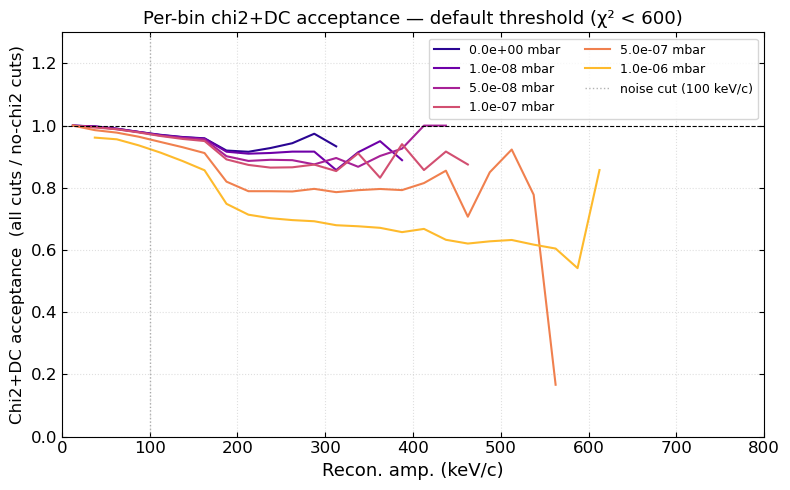

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for hh_a, hh_n, p, c in zip(hh_all_sel, hh_nochi2_sel, p_sel, colors):
    denom = hh_n.astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(denom > 5, hh_a / denom, np.nan)
    ax.plot(bc, ratio, color=c, lw=1.5, label=f'{p:.1e} mbar')

ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.axvline(hist.noise_threshold_kev, color='gray', ls=':', lw=1.0, alpha=0.6,
           label=f'noise cut ({hist.noise_threshold_kev:.0f} keV/c)')
ax.set_xlim(0, 800)
ax.set_ylim(0, 1.3)
ax.set_xlabel('Recon. amp. (keV/c)', fontsize=13)
ax.set_ylabel('Chi2+DC acceptance  (all cuts / no-chi2 cuts)', fontsize=12)
ax.set_title(f'Per-bin chi2+DC acceptance — default threshold (χ² < {hist.chi2_threshold:.0f})',
             fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, ls=':', alpha=0.4)
fig.tight_layout()

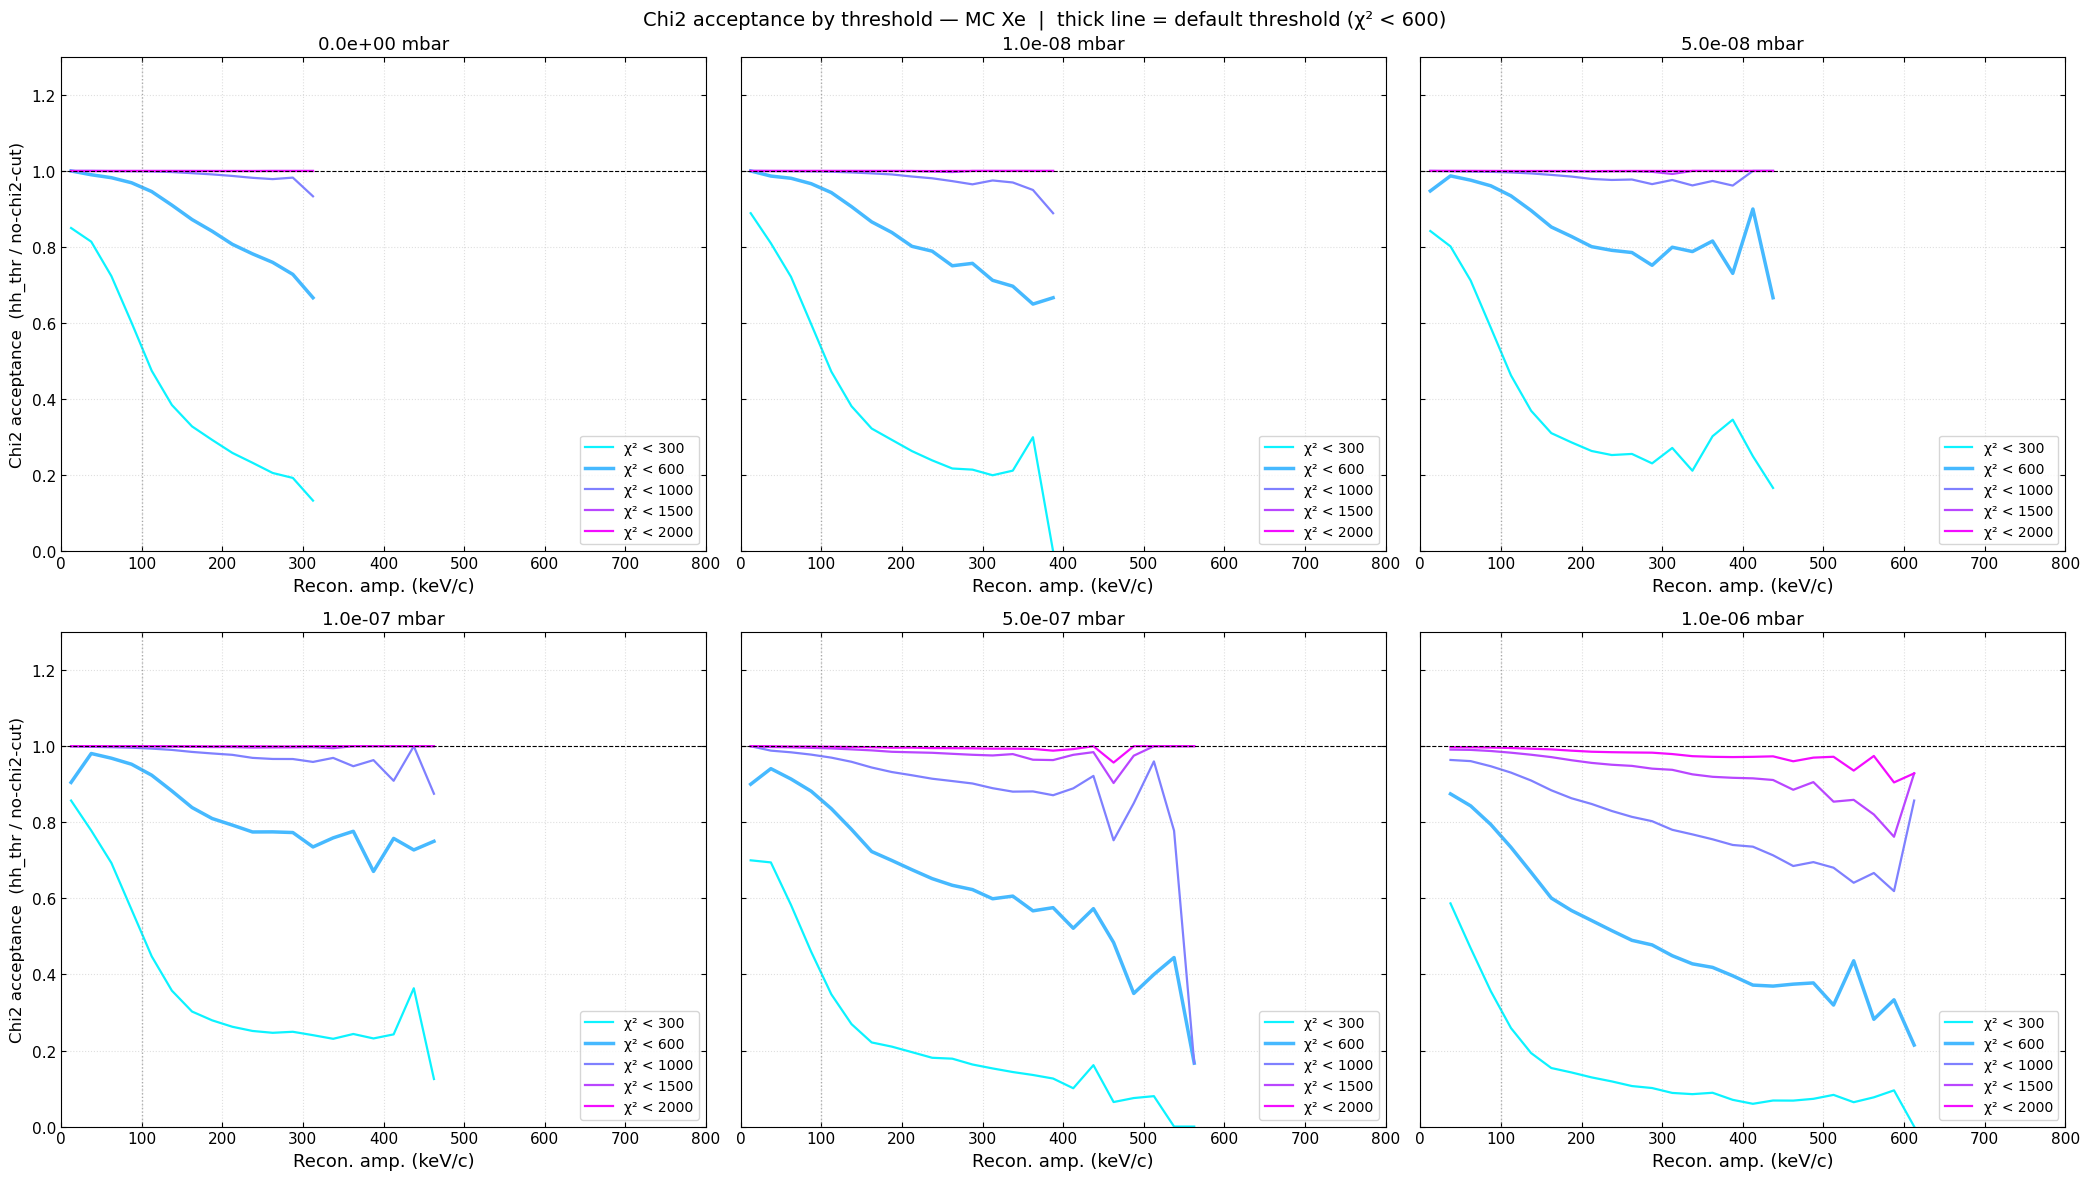

In [56]:
# ── Chi2 acceptance by threshold — 2×3 panels, one per selected pressure ──────
# Denominator: hh_thr[(p, np.inf)] — noise+drive cuts only, no chi2 cut
# Numerator:   hh_thr[(p, thr)]    — same but with chi2 < thr applied

finite_thrs   = [t for t in chi2_thresholds if t != np.inf]
thr_cols_fin  = plt.colormaps['cool'](np.linspace(0.05, 0.95, len(finite_thrs)))

ncols = 3
nrows = int(np.ceil(len(p_sel) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows), sharey=True)
axes_flat = np.array(axes).ravel()

for ax_idx, p in enumerate(p_sel):
    ax = axes_flat[ax_idx]
    denom = hh_thr[(p, np.inf)].astype(float)   # no chi2 cut = full denominator

    for thr, c in zip(finite_thrs, thr_cols_fin):
        hh = hh_thr[(p, thr)].astype(float)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(denom > 5, hh / denom, np.nan)
        lw = 2.5 if thr == hist.chi2_threshold else 1.6
        ax.plot(bc, ratio, color=c, lw=lw, label=f'χ² < {thr:.0f}')

    ax.axhline(1.0, color='k', ls='--', lw=0.8)
    ax.axvline(hist.noise_threshold_kev, color='gray', ls=':', lw=1.0, alpha=0.6)
    ax.set_xlim(0, 800)
    ax.set_ylim(0, 1.3)
    ax.set_xlabel('Recon. amp. (keV/c)', fontsize=13)
    ax.set_title(f'{p:.1e} mbar', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, ls=':', alpha=0.4)
    if ax_idx % ncols == 0:
        ax.set_ylabel('Chi2 acceptance  (hh_thr / no-chi2-cut)', fontsize=12)

for ax in axes_flat[len(p_sel):]:
    ax.set_visible(False)

fig.suptitle(
    f'Chi2 acceptance by threshold — MC Xe  |  '
    f'thick line = default threshold (χ² < {hist.chi2_threshold:.0f})',
    fontsize=14)
fig.tight_layout()

## Save histograms at each chi2 threshold

Saves `hh_thr[(p, thr)]` for every (pressure, threshold) combination to an HDF5 file
mirroring the structure of `recon_histograms.py`:

```
recon_histograms/
  bc                  — bin centres (keV/c)
  chi2_{thr}/         — one group per threshold (chi2_inf = no chi2 cut)
    {p_str}           — int64 histogram, attrs: pressure_mbar, chi2_threshold, unit
```

In [62]:
import os

outdir  = '../../data_processed/gas_recon'
outfile = os.path.join(outdir, 'mc_xe_chi2_scan.h5py')
os.makedirs(outdir, exist_ok=True)

unit = f'count/{bins[1]-bins[0]:.0f}keV'

with h5py.File(outfile, 'w') as fout:
    g = fout.create_group('recon_histograms')
    d = g.create_dataset('bc', data=bc, dtype=np.float64)
    d.attrs['unit'] = 'keV/c'

    # Store MC metadata once at root level
    fout.attrs['mc_gas']      = mc_meta[0]['mc_gas']
    fout.attrs['mc_T_gas']    = mc_meta[0]['mc_T_gas']
    fout.attrs['mc_T_sensor'] = mc_meta[0]['mc_T_sensor']
    fout.attrs['mc_alpha']    = mc_meta[0]['mc_alpha']

    for thr in chi2_thresholds:
        thr_str = 'inf' if thr == np.inf else f'{int(thr)}'
        grp = g.create_group(f'chi2_{thr_str}')

        for p in pressures:
            p_str = f'{p:.1e}mbar'
            hh = hh_thr[(p, thr)]
            d = grp.create_dataset(p_str, data=hh, dtype=np.int64)
            d.attrs['pressure_mbar']  = p
            d.attrs['chi2_threshold'] = thr if thr != np.inf else -1   # -1 encodes no cut
            d.attrs['unit'] = unit

print(f'Saved → {outfile}')
print(f'  Thresholds : {["inf" if t == np.inf else int(t) for t in chi2_thresholds]}')
print(f'  Pressures  : {[f"{p:.1e}" for p in pressures]}')

# Quick verification
with h5py.File(outfile, 'r') as f:
    grp_keys = list(f['recon_histograms'].keys())
    print(f'  Groups     : {grp_keys}')
    example_key = f'chi2_{int(hist.chi2_threshold)}'
    if example_key in f['recon_histograms']:
        pkeys = list(f['recon_histograms'][example_key].keys())
        print(f'  Pressures in {example_key}: {pkeys}')

Saved → ../../data_processed/gas_recon/mc_xe_chi2_scan.h5py
  Thresholds : [300, 600, 1000, 1500, 2000, 'inf']
  Pressures  : ['0.0e+00', '1.0e-08', '3.0e-08', '5.0e-08', '7.0e-08', '1.0e-07', '3.0e-07', '5.0e-07', '7.0e-07', '1.0e-06']
  Groups     : ['bc', 'chi2_1000', 'chi2_1500', 'chi2_2000', 'chi2_300', 'chi2_600', 'chi2_inf']
  Pressures in chi2_600: ['0.0e+00mbar', '1.0e-06mbar', '1.0e-07mbar', '1.0e-08mbar', '3.0e-07mbar', '3.0e-08mbar', '5.0e-07mbar', '5.0e-08mbar', '7.0e-07mbar', '7.0e-08mbar']
